In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu118 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 86.8 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 69.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 45.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 91.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 33.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.2 MB/s eta 0:00:0000:0100:01
     ━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00
Device : cuda
PyTorch: 2.3.1+cu118
Total available train samples: 3933
Train: 3146 | Val: 787

  Model  : SegMamba
  Params : 17.64M
  Device : cuda
  Ep 001 | Loss:0.7364 | Dice:0.4048 | IoU:0.2586 | PixAcc:0.9757 | Acc:0.9757 | Prec:0.3432 | Rec:0.5186 | Spec:0.9832
  Ep 010 | Loss:0.4706 | Dice:0.6626 | IoU:0.5038 | PixAcc:0.9877 | Acc:0.9877 | Prec:0.5861 | Rec:0.7793 | Spec:0.9911
  Ep 020 | Loss:0.2662 | Dice:0.7326 | IoU:0.5877 | PixAcc:0.9914 | Acc:0.9914 | Prec:0.7184 | Rec:0.7613 | Spec:0.9952
  Ep 030 | Loss:0.1794 | Dice:0.7563 | IoU:0.6175 | PixAcc:0.9927 | Acc:0.9927 | Prec:0.7944 | Rec:0.7335 | Spec:0.9970
  Ep 040 | Loss:0.1460 | Dice:0.7695 | IoU:0.6342 | PixAcc:0.9930 | Acc:0.9930 | Prec:0.7947 | Rec:0.7580 | Spec:0.9969
  Ep 050 | Loss:0.1287 | Dice:0.7799 | IoU:0.6486 | PixAcc:0.9934 | Acc:0.9934 | Prec:0.8167 | Rec:0.7580 | Spec:0.9973
  Ep 060 | Loss:0.1190 | Dice:0.7847 | IoU:0.6559 |

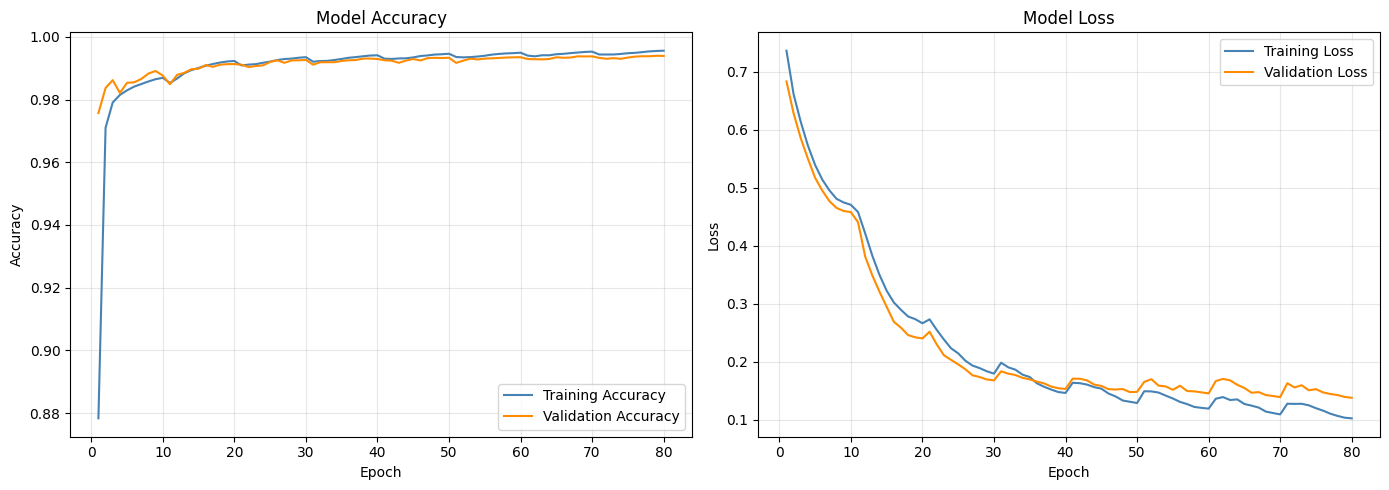

Plot saved to /kaggle/working/SegMamba_history.png

--- Evaluating on Train Set ---
Total available train samples: 3933
Train: 3146 | Val: 787

  TRAIN EVALUATION
  Loss       : 0.1032
  Dice       : 84.92%
  IoU        : 74.31%
  Pixel Acc  : 99.52%
  Accuracy   : 99.52%
  Precision  : 85.93%
  Recall     : 84.48%
  Specificity: 99.77%

--- Evaluating on Validation Set ---
Total available train samples: 3933
Train: 3146 | Val: 787

  VALIDATION EVALUATION
  Loss       : 0.1071
  Dice       : 84.55%
  IoU        : 73.80%
  Pixel Acc  : 99.51%
  Accuracy   : 99.51%
  Precision  : 85.74%
  Recall     : 84.02%
  Specificity: 99.76%

--- Evaluating on Test Set ---
Total available test samples: 860
Using test samples: 860

  TEST EVALUATION
  Loss       : 0.1294
  Dice       : 81.16%
  IoU        : 70.00%
  Pixel Acc  : 99.36%
  Accuracy   : 99.36%
  Precision  : 82.03%
  Recall     : 82.07%
  Specificity: 99.70%

[FINAL RESULT] SegMamba → Val Dice: 79.97% | Test IoU: 70.00%


In [2]:
import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch", "einops", "-q"], check=True)

import os, glob, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

BASE_PATH     = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "segmentation_task/train/images")
TRAIN_MSK_DIR = os.path.join(BASE_PATH, "segmentation_task/train/masks")
TEST_IMG_DIR  = os.path.join(BASE_PATH, "segmentation_task/test/images")
TEST_MSK_DIR  = os.path.join(BASE_PATH, "segmentation_task/test/masks")

CFG = dict(
    img_size     = 256,
    batch_size   = 8,
    lr           = 1e-4,
    weight_decay = 1e-5,
    epochs       = 80,
    patience     = 10,
    device       = "cuda" if torch.cuda.is_available() else "cpu",
)
print(f"Device : {CFG['device']}")
print(f"PyTorch: {torch.__version__}")


class BraTSDataset(Dataset):
    def __init__(self, img_paths, mask_paths, img_size=256, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.img_size   = img_size
        self.augment    = augment

    def __len__(self):
        return len(self.img_paths)

    def _load(self, path, gray=False):
        img = Image.open(path).convert("L" if gray else "RGB")
        return img.resize((self.img_size, self.img_size), Image.BILINEAR)

    def __getitem__(self, idx):
        img  = self._load(self.img_paths[idx])
        mask = self._load(self.mask_paths[idx], gray=True)
        if self.augment:
            if random.random() > 0.5: img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() > 0.5: img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            if angle:
                img  = TF.rotate(img,  angle)
                mask = TF.rotate(mask, angle)
            img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
            img = TF.adjust_contrast(img,   random.uniform(0.8, 1.2))
        img  = TF.to_tensor(img)
        img  = TF.normalize(img, [0.5]*3, [0.5]*3)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask


def get_loaders():
    all_img_paths  = sorted(glob.glob(os.path.join(TRAIN_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TRAIN_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No images found at {TRAIN_IMG_DIR}"
    assert len(all_img_paths) == len(all_mask_paths), "Image/mask count mismatch!"
    print(f"Total available train samples: {len(all_img_paths)}")

    idx = list(range(len(all_img_paths)))
    random.shuffle(idx)
    split  = int(0.8 * len(idx))
    t_idx  = idx[:split]
    v_idx  = idx[split:]

    train_ds = BraTSDataset([all_img_paths[i] for i in t_idx],
                             [all_mask_paths[i] for i in t_idx],
                             CFG["img_size"], augment=True)
    val_ds   = BraTSDataset([all_img_paths[i] for i in v_idx],
                             [all_mask_paths[i] for i in v_idx],
                             CFG["img_size"], augment=False)
    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True,  num_workers=4, pin_memory=True,
                              persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=4, pin_memory=True,
                              persistent_workers=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
    return train_loader, val_loader


def get_test_loader():
    all_img_paths  = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TEST_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No test images found at {TEST_IMG_DIR}"
    print(f"Total available test samples: {len(all_img_paths)}")

    test_ds = BraTSDataset(all_img_paths, all_mask_paths, CFG["img_size"], augment=False)
    print(f"Using test samples: {len(test_ds)}")
    return DataLoader(test_ds, batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=4, pin_memory=True,
                      persistent_workers=True)


class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2, 3))
        dice  = 1 - (2*inter + self.smooth) / (
                    prob.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return 0.5 * dice.mean() + 0.5 * bce


def compute_metrics(logits, masks, thresh=0.5):
    preds = (torch.sigmoid(logits) > thresh).float()
    inter = (preds * masks).sum()
    dice  = (2*inter + 1) / (preds.sum() + masks.sum() + 1)
    iou   = (inter + 1)   / (preds.sum() + masks.sum() - inter + 1)
    acc   = (preds == masks).float().mean()
    tp    = ((preds==1)&(masks==1)).sum().float()
    tn    = ((preds==0)&(masks==0)).sum().float()
    fp    = ((preds==1)&(masks==0)).sum().float()
    fn    = ((preds==0)&(masks==1)).sum().float()
    prec  = tp / (tp + fp + 1e-7)
    rec   = tp / (tp + fn + 1e-7)
    spec  = tn / (tn + fp + 1e-7)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    return dice.item(), iou.item(), acc.item(), prec.item(), rec.item(), spec.item(), pixel_acc.item()


def evaluate_split(model, loader, device, split_name):
    model.eval()
    criterion = DiceBCELoss()
    total_loss = 0.0
    v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                out = model(imgs)
                if out.shape[-2:] != masks.shape[-2:]:
                    out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                total_loss += criterion(out, masks).item()
            d, i, a, p, r, s, px = compute_metrics(out, masks)
            v_dice += d; v_iou += i; v_acc += a
            v_prec += p; v_rec += r; v_spec += s; v_pix += px
    n = len(loader)
    print(f"\n{'='*60}")
    print(f"  {split_name} EVALUATION")
    print(f"{'='*60}")
    print(f"  Loss       : {total_loss/n:.4f}")
    print(f"  Dice       : {v_dice/n*100:.2f}%")
    print(f"  IoU        : {v_iou/n*100:.2f}%")
    print(f"  Pixel Acc  : {v_pix/n*100:.2f}%")
    print(f"  Accuracy   : {v_acc/n*100:.2f}%")
    print(f"  Precision  : {v_prec/n*100:.2f}%")
    print(f"  Recall     : {v_rec/n*100:.2f}%")
    print(f"  Specificity: {v_spec/n*100:.2f}%")
    print(f"{'='*60}")
    return v_dice/n, v_iou/n


def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history["train_acc"], color='steelblue',  linewidth=1.5, label="Training Accuracy")
    axes[0].plot(epochs, history["val_acc"],   color='darkorange', linewidth=1.5, label="Validation Accuracy")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["train_loss"], color='steelblue',  linewidth=1.5, label="Training Loss")
    axes[1].plot(epochs, history["val_loss"],   color='darkorange', linewidth=1.5, label="Validation Loss")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{model_name}_history.png", dpi=150)
    plt.show()
    print(f"Plot saved to /kaggle/working/{model_name}_history.png")


class SSMCore(nn.Module):
    def __init__(self, dim, d_state=8, d_conv=4):
        super().__init__()
        self.dim     = dim
        self.d_state = d_state
        self.in_proj = nn.Linear(dim, dim * 2, bias=False)
        self.conv1d  = nn.Conv1d(dim, dim, kernel_size=d_conv,
                                 padding=d_conv - 1, groups=dim, bias=True)
        self.act     = nn.SiLU()
        self.x_proj  = nn.Linear(dim, d_state * 2 + dim, bias=False)
        self.dt_proj = nn.Linear(dim, dim, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).repeat(dim, 1)
        self.A_log   = nn.Parameter(torch.log(A))
        self.D       = nn.Parameter(torch.ones(dim))
        self.out_norm = nn.LayerNorm(dim)
        self.out_proj = nn.Linear(dim, dim, bias=False)
        nn.init.constant_(self.dt_proj.bias, -2.0)

    def forward(self, x):
        B, L, C  = x.shape
        xz       = self.in_proj(x)
        x_in, z  = xz.chunk(2, dim=-1)
        xc       = self.conv1d(x_in.transpose(1, 2))[:, :, :L].transpose(1, 2)
        xc       = self.act(xc)
        xd       = self.x_proj(xc)
        B_s      = xd[:, :, :self.d_state]
        C_s      = xd[:, :, self.d_state:self.d_state * 2]
        dt       = F.softplus(self.dt_proj(xd[:, :, self.d_state * 2:]).clamp(-10, 10))
        A        = -torch.exp(self.A_log.float().clamp(-8, 2))

        dA  = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))
        dBx = dt.unsqueeze(-1) * B_s.unsqueeze(2) * xc.unsqueeze(-1)

        y = self._parallel_scan(dA, dBx, C_s)
        y = y + xc * self.D.unsqueeze(0).unsqueeze(0)
        y = self.out_norm(y) * F.silu(z)
        return self.out_proj(y)

    def _parallel_scan(self, dA, dBx, C_s):
        B, L, d, s = dA.shape
        log_dA  = torch.log(dA.clamp(min=1e-6))
        cum_log = torch.cumsum(log_dA, dim=1)
        scale   = torch.exp(cum_log)
        scaled_dBx = dBx / scale.clamp(min=1e-6)
        cum_scaled = torch.cumsum(scaled_dBx, dim=1)
        h_all   = scale * cum_scaled
        h_all   = h_all.clamp(-1e4, 1e4)
        y       = (h_all * C_s.unsqueeze(2)).sum(-1)
        return y


class MambaBlock(nn.Module):
    def __init__(self, dim, d_state=8, d_conv=4, mlp_ratio=2):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.ssm   = SSMCore(dim, d_state=d_state, d_conv=d_conv)
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim    = int(dim * mlp_ratio)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x = x + self.ssm(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class TriDirectionalMamba(nn.Module):
    def __init__(self, dim, d_state=8, d_conv=4, mlp_ratio=2):
        super().__init__()
        self.mamba_row = MambaBlock(dim, d_state, d_conv, mlp_ratio)
        self.mamba_col = MambaBlock(dim, d_state, d_conv, mlp_ratio)  # fixed typo: MambbBlock -> MambaBlock
        self.mamba_dep = MambaBlock(dim, d_state, d_conv, mlp_ratio)
        self.norm      = nn.LayerNorm(dim)
        self.merge     = nn.Linear(dim * 3, dim, bias=False)

    def forward(self, x, H, W):
        B, L, C = x.shape
        x2d     = x.reshape(B, H, W, C)
        row_out = self.mamba_row(x2d.reshape(B * H, W, C)).reshape(B, H, W, C).reshape(B, L, C)
        col_out = self.mamba_col(x2d.permute(0, 2, 1, 3).reshape(B * W, H, C)).reshape(B, W, H, C).permute(0, 2, 1, 3).reshape(B, L, C)
        dep_out = self.mamba_dep(x)
        merged  = self.merge(torch.cat([row_out, col_out, dep_out], dim=-1))
        return x + self.norm(merged)


class SegMambaPatchEmbed(nn.Module):
    def __init__(self, in_ch=3, embed_dim=256, patch_size=16):
        super().__init__()
        stride2 = patch_size // 2
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch, embed_dim // 2, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=stride2, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim),
        )

    def forward(self, x):
        x       = self.proj(x)
        B, C, H, W = x.shape
        return x.flatten(2).transpose(1, 2), H, W


class SegMambaEncoder(nn.Module):
    def __init__(self, in_ch=3, embed_dim=256, patch_size=16,
                 depth=8, img_size=256, d_state=8):
        super().__init__()
        self.patch_embed = SegMambaPatchEmbed(in_ch, embed_dim, patch_size)
        num_patches      = (img_size // patch_size) ** 2
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.layers      = nn.ModuleList([
            TriDirectionalMamba(embed_dim, d_state=d_state, d_conv=4, mlp_ratio=2)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.neck = nn.Sequential(
            nn.Conv2d(embed_dim, 256, 1, bias=False),
            nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B            = x.shape[0]
        tok, H, W    = self.patch_embed(x)
        tok          = tok + self.pos_embed
        for layer in self.layers:
            tok = layer(tok, H, W)
        tok  = self.norm(tok)
        feat = tok.transpose(1, 2).reshape(B, -1, H, W)
        return self.neck(feat)


class SegMambaSkipBlock(nn.Module):
    def __init__(self, dim, d_state=8):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.ssm  = SSMCore(dim, d_state=d_state, d_conv=4)

    def forward(self, x):
        B, C, H, W = x.shape
        seq = x.flatten(2).transpose(1, 2)
        seq = seq + self.ssm(self.norm(seq))
        return seq.transpose(1, 2).reshape(B, C, H, W)


class SegMambaDecoder(nn.Module):
    def __init__(self, img_feat_ch=256, num_classes=1):
        super().__init__()
        self.skip0 = SegMambaSkipBlock(img_feat_ch, d_state=8)
        self.up1   = nn.Sequential(nn.ConvTranspose2d(img_feat_ch, 128, 2, stride=2), nn.BatchNorm2d(128), nn.GELU())
        self.skip1 = SegMambaSkipBlock(128, d_state=8)
        self.up2   = nn.Sequential(nn.ConvTranspose2d(128, 64, 2, stride=2), nn.BatchNorm2d(64), nn.GELU())
        self.skip2 = SegMambaSkipBlock(64, d_state=8)
        self.up3   = nn.Sequential(nn.ConvTranspose2d(64, 32, 2, stride=2), nn.BatchNorm2d(32), nn.GELU())
        self.skip3 = SegMambaSkipBlock(32, d_state=8)
        self.up4   = nn.Sequential(nn.ConvTranspose2d(32, 16, 2, stride=2), nn.BatchNorm2d(16), nn.GELU())
        self.dropout = nn.Dropout2d(0.3)
        self.head    = nn.Conv2d(16, num_classes, 1)

    def forward(self, feat):
        x = self.skip0(feat)
        x = self.skip1(self.up1(x))
        x = self.skip2(self.up2(x))
        x = self.skip3(self.up3(x))
        x = self.up4(x)
        return self.head(self.dropout(x))


class SegMamba(nn.Module):
    def __init__(self, in_ch=3, num_classes=1, img_size=256):
        super().__init__()
        self.encoder = SegMambaEncoder(
            in_ch=in_ch, embed_dim=256, patch_size=16,
            depth=8, img_size=img_size, d_state=8,
        )
        self.decoder = SegMambaDecoder(img_feat_ch=256, num_classes=num_classes)

    def forward(self, x):
        feat = self.encoder(x)
        out  = self.decoder(feat)
        if out.shape[-2:] != x.shape[-2:]:
            out = F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return out


def train_model(model, model_name):
    device = CFG["device"]
    model  = model.to(device)
    train_loader, val_loader = get_loaders()
    criterion = DiceBCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)
    scaler    = torch.cuda.amp.GradScaler()
    best_dice, no_improve = 0.0, 0
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  Model  : {model_name}")
    print(f"  Params : {n_params/1e6:.2f}M")
    print(f"  Device : {device}")
    print(f"{'='*60}")
    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        t_loss = t_acc = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                out = model(imgs)
                if out.shape[-2:] != masks.shape[-2:]:
                    out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                loss = criterion(out, masks)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()
            with torch.no_grad():
                _, _, a, _, _, _, _ = compute_metrics(out, masks)
            t_acc += a
        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)
        model.eval()
        v_loss = v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
                with torch.cuda.amp.autocast():
                    out = model(imgs)
                    if out.shape[-2:] != masks.shape[-2:]:
                        out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                    v_loss += criterion(out, masks).item()
                d, i, a, p, r, s, px = compute_metrics(out, masks)
                v_dice += d; v_iou += i; v_acc += a
                v_prec += p; v_rec += r; v_spec += s; v_pix += px
        n = len(val_loader)
        v_loss /= n; v_dice /= n; v_iou /= n; v_acc /= n
        v_prec /= n; v_rec /= n; v_spec /= n; v_pix /= n
        scheduler.step()
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:03d} | Loss:{t_loss:.4f} | "
                  f"Dice:{v_dice:.4f} | IoU:{v_iou:.4f} | "
                  f"PixAcc:{v_pix:.4f} | Acc:{v_acc:.4f} | "
                  f"Prec:{v_prec:.4f} | Rec:{v_rec:.4f} | Spec:{v_spec:.4f}")
        if v_dice > best_dice:
            best_dice    = v_dice
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= CFG["patience"]:
                print(f"  Early stop at epoch {epoch}.")
                break
    model.load_state_dict(best_weights)
    print(f"\n{'='*60}")
    print(f"  {model_name} TRAINING COMPLETE")
    print(f"  Best Val Dice : {best_dice*100:.2f}%")
    print(f"{'='*60}")
    plot_history(history, model_name)
    print("\n--- Evaluating on Train Set ---")
    train_loader_eval, _ = get_loaders()
    evaluate_split(model, train_loader_eval, device, "TRAIN")
    print("\n--- Evaluating on Validation Set ---")
    _, val_loader_eval = get_loaders()
    evaluate_split(model, val_loader_eval, device, "VALIDATION")
    print("\n--- Evaluating on Test Set ---")
    test_loader = get_test_loader()
    test_dice, test_iou = evaluate_split(model, test_loader, device, "TEST")
    return model, history, best_dice, test_iou


torch.cuda.empty_cache()
model_segmamba = SegMamba(in_ch=3, num_classes=1, img_size=256)
model_segmamba, history_segmamba, dice_segmamba, iou_segmamba = train_model(model_segmamba, "SegMamba")
print(f"\n[FINAL RESULT] SegMamba → Val Dice: {dice_segmamba*100:.2f}% | Test IoU: {iou_segmamba*100:.2f}%")